In [1]:
import json
import pandas as pd
import h5py
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Input, Dense, Dropout, LSTM, Flatten, GRU,TimeDistributed, Conv1D, BatchNormalization
from keras.models import Model, Sequential
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
import os
import h5py
import matplotlib.pyplot as plt
from keras import regularizers
from tensorflow.keras.regularizers import l1
import ast
from tqdm import tqdm
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, truncnorm, randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import loguniform
from pandas import read_csv
# from keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import roc_auc_score
from qkeras import *
import qkeras
from tensorflow.keras.models import load_model
from qkeras.utils import model_quantize
from qkeras.utils import model_save_quantized_weights

import matplotlib.pyplot as plt

2025-11-09 20:54:18.823487: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-09 20:54:18.825560: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-09 20:54:18.853877: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-09 20:54:18.853902: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-09 20:54:18.855170: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
# generate test data
X_test = np.load('data/X_test.npy', allow_pickle=True)
y_test = np.load('data/y_test.npy', allow_pickle=True)

X_testzero = np.zeros((len(X_test), 100, 3))

for x in range(len(X_test)):
    for y in range(100):
        for z in range(3):
            if y >= len(X_test[x]):
                break
            X_testzero[x][y][z] = X_test[x][y][z]

# encode labels for 5 classes
num_classes = 5
y_labhot = np.zeros((len(y_test),5))

y_labhot.shape

num = 0
for x in y_test:
  if x == 0:
    y_labhot[num][0] = 1
  elif x == 1: 
    y_labhot[num][1] = 1
  elif x == 2: 
    y_labhot[num][2] = 1
  elif x == 3: 
    y_labhot[num][3] = 1
  elif x == 4: 
    y_labhot[num][4] = 1
  num = num + 1

In [ ]:
# create hls4ml model
import hls4ml
import plotting

model = load_model('./gru/Quickdraw5Class1_20.h5')
y_keras = model.predict(X_testzero, batch_size=512)

config = hls4ml.utils.config_from_keras_model(model, granularity='model')

print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vivado', output_dir='model_1/hls4ml_gru', part='xc7vx690tffg1761-2'
)

hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

25/25 [==============================] - 1s 19ms/step


KeyError: 'LayerName'

-----------------------------------
Configuration
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  input_1
    Trace:           True
    Precision
      result:        auto
  gru
    Trace:           True
    Precision
      result:        auto
      weight:        auto
      bias:          auto
      recurrent_weight:auto
      recurrent_bias:auto
  flatten
    Trace:           True
    Precision
      result:        auto
  dense
    Trace:           True
    Precision
      result:        auto
      weight:        auto
      bias:          auto
  dense_linear
    Trace:           True
    Precision
      result:        auto
  relu_0
    Trace:           True
    Precision
      result:        auto
  dense_1
    Trace:           True
    Precision
      result:        auto
      weight:        auto
      bias:          auto
  dense_1_linear
    Trace:           

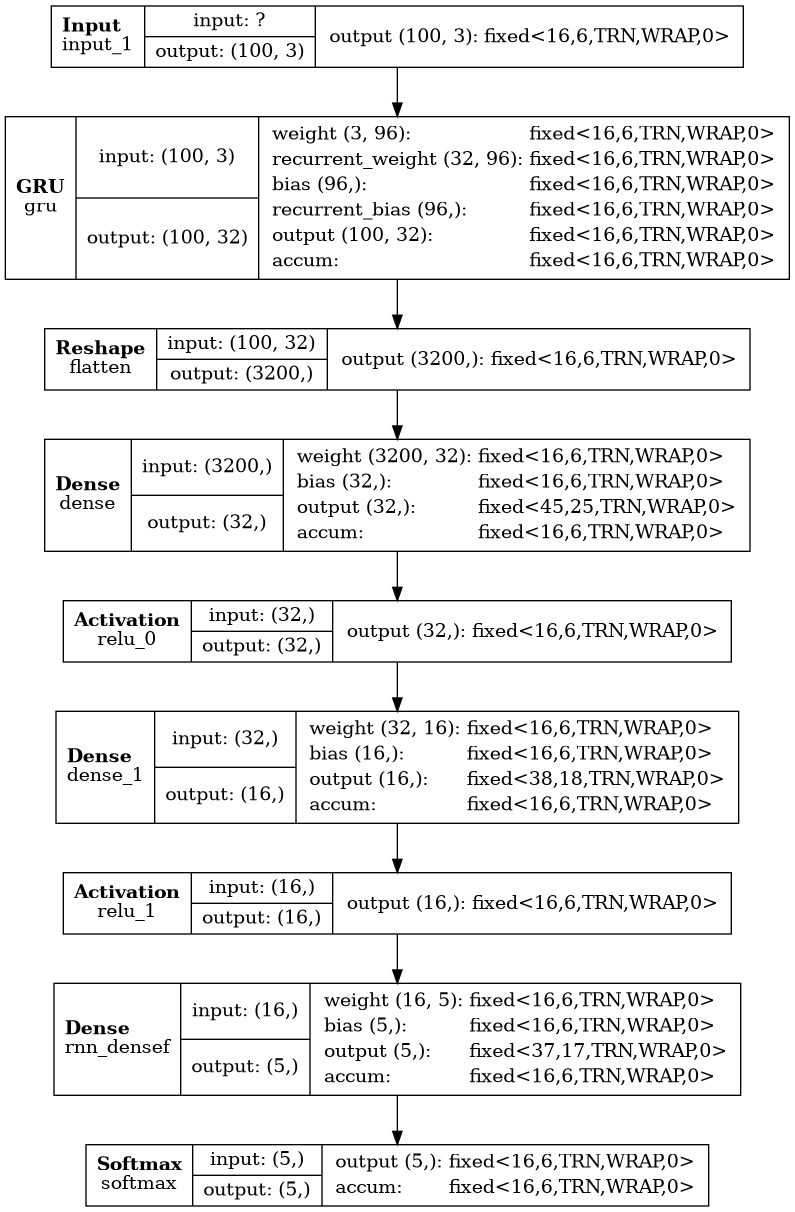

In [15]:
# create hls4ml model - edited (name)

config_name = hls4ml.utils.config_from_keras_model(model, granularity='name')

for layer in config_name['LayerName'].keys():
    config_name['LayerName'][layer]['Trace'] = True
    config_name['LayerName']['softmax']['exp_table_t'] = 'ap_fixed<32,16>'
    config_name['LayerName']['softmax']['inv_table_t'] = 'ap_fixed<32,16>'
    config_name['LayerName']['softmax']['table_size'] = 4096

print("-----------------------------------")
print("Configuration")
plotting.print_dict(config_name)
print("-----------------------------------")
hls_model_name = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config_name, backend='Vivado', output_dir='model_1/hls4ml_gru/name', part='xc7vx690tffg1761-2'
)

hls4ml.utils.plot_model(hls_model_name, show_shapes=True, show_precision=True, to_file=None)

In [16]:
hls_model.compile()

In [17]:
X_testzero_contig = np.ascontiguousarray(X_testzero)
y_hls = hls_model.predict(X_testzero_contig)

In [18]:
hls_model_name.compile()
y_hls_name = hls_model_name.predict(X_testzero_contig)

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()

y_pred_hls = np.argmax(y_hls, axis=1)
y_true_hls = np.argmax(y_labhot, axis=1)

print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_labhot, axis=1), np.argmax(y_keras, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_labhot, axis=1), np.argmax(y_hls, axis=1))))

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true_hls, y_pred_hls, target_names=['ant', 'bee', 'butterfly', 'mosquito', 'snail']))

# fig, ax = plt.subplots(figsize=(9, 9))
# _ = plotting.makeRoc(y_test, y_keras, le.classes_)
# plt.gca().set_prop_cycle(None)  # reset the colors
# _ = plotting.makeRoc(y_test, y_hls, le.classes_, linestyle='--')

# from matplotlib.lines import Line2D

# lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
# from matplotlib.legend import Legend

# leg = Legend(ax, lines, labels=['keras', 'hls4ml'], loc='lower right', frameon=False)
# ax.add_artist(leg)

Keras  Accuracy: 0.92304
hls4ml Accuracy: 0.29472
              precision    recall  f1-score   support

         ant       0.44      0.27      0.33      2500
         bee       0.41      0.10      0.16      2500
   butterfly       0.53      0.19      0.28      2500
    mosquito       0.23      0.85      0.37      2500
       snail       0.44      0.07      0.11      2500

    accuracy                           0.29     12500
   macro avg       0.41      0.29      0.25     12500
weighted avg       0.41      0.29      0.25     12500



In [20]:

print(y_hls)
print(y_labhot)
print(y_pred_hls)
print(y_true_hls)

print(y_hls[0])
print(np.argmax(y_hls[0]))

[[0.05859375 0.04003906 0.00390625 1.         0.00390625]
 [0.06738281 0.14746094 0.         0.79980469 0.        ]
 [0.015625   0.15332031 0.00390625 1.         0.0078125 ]
 ...
 [0.01757812 0.04101562 0.14746094 0.79980469 0.03125   ]
 [0.0703125  0.09277344 0.01074219 1.         0.01074219]
 [0.01269531 0.01171875 0.         1.         0.        ]]
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]
[3 3 3 ... 3 3 3]
[0 0 0 ... 4 4 4]
[0.05859375 0.04003906 0.00390625 1.         0.00390625]
3


In [21]:
y_pred = np.argmax(y_hls_name, axis=1)
y_true = np.argmax(y_labhot, axis=1)

print("hls4ml name  Accuracy: {}".format(accuracy_score(np.argmax(y_labhot, axis=1), np.argmax(y_hls_name, axis=1))))

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=['ant', 'bee', 'butterfly', 'mosquito', 'snail']))

hls4ml name  Accuracy: 0.18512
              precision    recall  f1-score   support

         ant       0.19      0.88      0.31      2500
         bee       0.14      0.05      0.07      2500
   butterfly       1.00      0.00      0.00      2500
    mosquito       0.00      0.00      0.00      2500
       snail       0.00      0.00      0.00      2500

    accuracy                           0.19     12500
   macro avg       0.27      0.19      0.08     12500
weighted avg       0.27      0.19      0.08     12500



/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [22]:
name_predict, name_trace =  hls_model_name.trace(X_testzero)

Recompiling myproject with tracing


In [23]:
print(name_trace['rnn_densef'])
print(name_trace['softmax'])

[[  0.42382812   0.04199219  -2.26855469   3.28222656  -2.25878906]
 [  5.4296875    6.22558594 -12.5          7.91503906 -10.99121094]
 [ -0.57910156   1.75683594  -1.94921875   3.63671875  -1.29394531]
 ...
 [ -1.80175781  -0.93066406   0.32714844   2.04003906  -1.18164062]
 [ -0.03710938   0.24804688  -1.86328125   2.63671875  -1.92285156]
 [  0.12402344   0.05957031  -3.20996094   4.52441406  -5.52050781]]
[[0.19921875 0.19921875 0.19921875 0.19921875 0.19921875]
 [0.33300781 0.33300781 0.         0.33300781 0.        ]
 [0.19921875 0.19921875 0.19921875 0.19921875 0.19921875]
 ...
 [0.19921875 0.19921875 0.19921875 0.19921875 0.19921875]
 [0.19921875 0.19921875 0.19921875 0.19921875 0.19921875]
 [0.19921875 0.19921875 0.19921875 0.19921875 0.19921875]]


-----------------------------------
Configuration
Model
  Precision
    default:         ap_fixed<32,16>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  input_1
    Trace:           False
    Precision
      result:        auto
  gru
    Trace:           False
    Precision
      result:        auto
      weight:        auto
      bias:          auto
      recurrent_weight:auto
      recurrent_bias:auto
  flatten
    Trace:           False
    Precision
      result:        auto
  dense
    Trace:           False
    Precision
      result:        auto
      weight:        auto
      bias:          auto
  dense_linear
    Trace:           False
    Precision
      result:        auto
  relu_0
    Trace:           False
    Precision
      result:        auto
  dense_1
    Trace:           False
    Precision
      result:        auto
      weight:        auto
      bias:          auto
  dense_1_linear
    Trace:

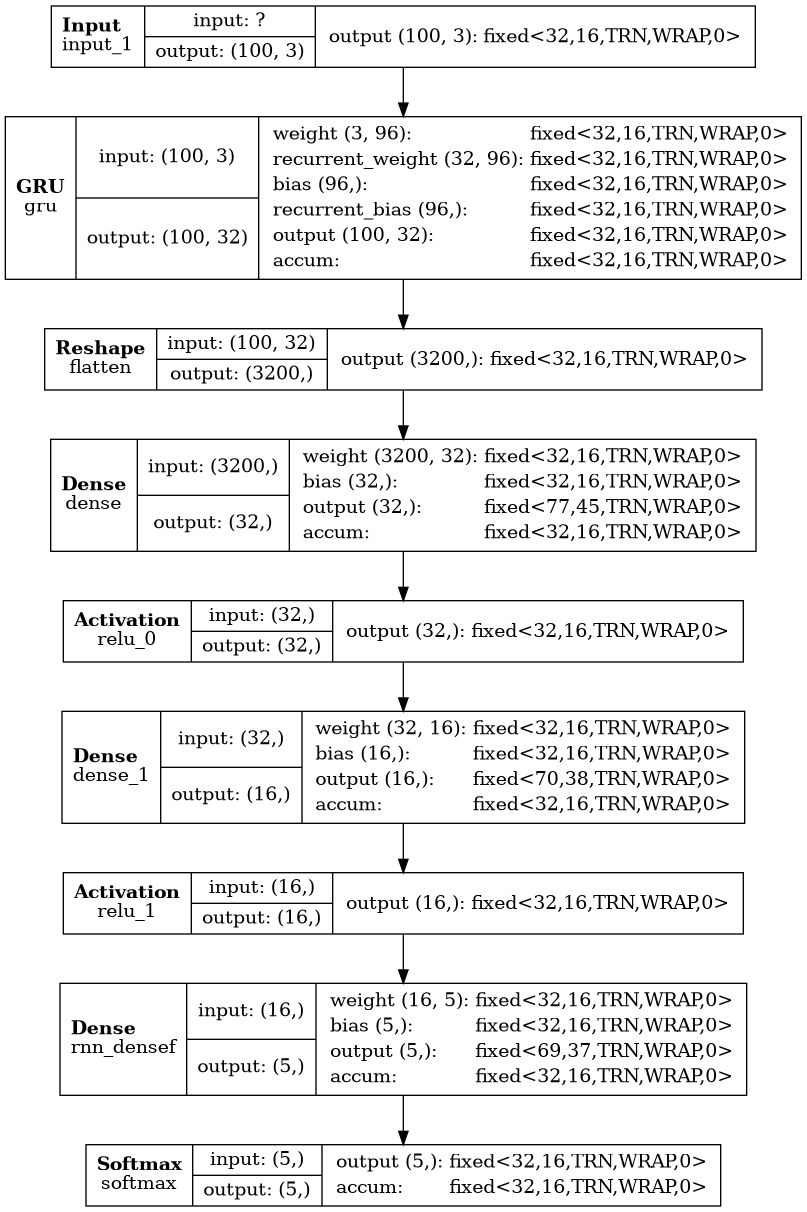

In [24]:
# create hls4ml model - high bitwidth

config_high = hls4ml.utils.config_from_keras_model(model, granularity='name', default_precision='ap_fixed<32,16>')
print("-----------------------------------")
print("Configuration")
plotting.print_dict(config_high)
print("-----------------------------------")
hls_model_high = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config_high,
    backend='Vivado',
    output_dir='model_1/hls4ml_gru/high',
    part='xc7vx690tffg1761-2'
)

hls4ml.utils.plot_model(hls_model_high, show_shapes=True, show_precision=True, to_file=None)

In [25]:
hls_model_high.compile()
X_testzero_contig = np.ascontiguousarray(X_testzero)
y_hls_high = hls_model_high.predict(X_testzero_contig)

y_pred = np.argmax(y_hls_high, axis=1)
y_true = np.argmax(y_labhot, axis=1)

print("hls4ml high  Accuracy: {}".format(accuracy_score(np.argmax(y_labhot, axis=1), np.argmax(y_hls_high, axis=1))))

print(classification_report(y_true, y_pred, target_names=['ant', 'bee', 'butterfly', 'mosquito', 'snail']))

hls4ml high  Accuracy: 0.2
              precision    recall  f1-score   support

         ant       0.20      1.00      0.33      2500
         bee       0.00      0.00      0.00      2500
   butterfly       0.00      0.00      0.00      2500
    mosquito       0.00      0.00      0.00      2500
       snail       0.00      0.00      0.00      2500

    accuracy                           0.20     12500
   macro avg       0.04      0.20      0.07     12500
weighted avg       0.04      0.20      0.07     12500



/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [26]:
print(y_hls_high)
print(y_labhot)
print(y_pred)
print(y_true)

[[0.20019531 0.20019531 0.20019531 0.20019531 0.20019531]
 [0.20019531 0.20019531 0.20019531 0.20019531 0.20019531]
 [0.20019531 0.20019531 0.20019531 0.20019531 0.20019531]
 ...
 [0.20019531 0.20019531 0.20019531 0.20019531 0.20019531]
 [0.20019531 0.20019531 0.20019531 0.20019531 0.20019531]
 [0.20019531 0.20019531 0.20019531 0.20019531 0.20019531]]
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]
[0 0 0 ... 0 0 0]
[0 0 0 ... 4 4 4]


In [27]:
import hls4ml.model.profiling as profiling

def safe_get_ymodel_keras(keras_model, X):
    from tensorflow.keras import Model
    # create a new model that outputs all layer outputs
    layer_outputs = [layer.output for layer in keras_model.layers if hasattr(layer, 'output')]
    return Model(inputs=keras_model.input, outputs=layer_outputs).predict(X)

# replace the broken version
profiling.get_ymodel_keras = safe_get_ymodel_keras

keras_trace = profiling.get_ymodel_keras(model, X_testzero)

# keras_trace = get_ymodel_keras(model, X_testzero)

# print('keras:')
# print(keras_trace)
# print('hls4ml:')
# print(trace_outputs)

391/391 [==============================] - 2s 5ms/step


In [28]:
print("keras layer 'gru', first sample:")
print(keras_trace['gru'][0])
print("hls4ml layer 'gru', first sample:")
print(name_trace['gru'][0])

keras layer 'gru', first sample:


TypeError: list indices must be integers or slices, not str